# Scammed Young – Data Visualisation Project

This notebook loads, cleans, and analyses the uploaded datasets for the scam-harm project.

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


## File Paths

In [ ]:
DATA_DIR = Path('data')

SCAMWATCH_FILE = DATA_DIR / 'Scamwatch903 Public Scams Dashboard - Export.csv'
ABS_FILE = DATA_DIR / '32350DS0003_2024.xlsx'
COMM_FILE = DATA_DIR / 'How we communicate data tables.xlsx'
ACMA_RAWFILE = DATA_DIR / 'Data files - Action on scams spam and telemarketing October to December 2025.xlsx'
ACMA_FILE = DATA_DIR / 'ACMA_clea

## Helper Functions

In [136]:
def money_to_float(value):
    if pd.isna(value):
        return 0.0
    cleaned = re.sub(r'[^0-9.\\-]', '', str(value))
    return float(cleaned) if cleaned else 0.0

def standardise_state_name(value):
    mapping = {
        'Australian Capital Territory': 'ACT',
        'New South Wales': 'NSW',
        'Northern Territory': 'NT',
        'Queensland': 'QLD',
        'South Australia': 'SA',
        'Tasmania': 'TAS',
        'Victoria': 'VIC',
        'Western Australia': 'WA'
    }
    return mapping.get(str(value).strip(), str(value).strip())


## Load Scamwatch Dataset

In [137]:
scam_df = pd.read_csv(SCAMWATCH_FILE)

scam_df = scam_df.rename(columns={
    'StartOfMonth': 'month',
    'Address_State': 'state_name',
    'Scam___Contact_Mode': 'contact_mode',
    'Complainant_Age': 'age_group',
    'Complainant_Gender': 'gender',
    'Category_Level_3': 'scam_category',
    'Amount_lost': 'amount_lost',
    'Number_of_reports': 'reports'
})

scam_df['month'] = pd.to_datetime(scam_df['month'])
scam_df['amount_lost'] = scam_df['amount_lost'].apply(money_to_float)
scam_df['reports'] = pd.to_numeric(scam_df['reports'], errors='coerce').fillna(0)
scam_df['state'] = scam_df['state_name'].apply(standardise_state_name)

scam_df.head()

,month,state_name,contact_mode,age_group,gender,scam_category,amount_lost,reports,state
0,2025-01-01,New South Wales,Email,65 and over,Male,Phishing scams,26549.99,326,NSW
1,2025-02-01,New South Wales,Email,65 and over,Male,Phishing scams,3.19,303,NSW
2,2025-03-01,New South Wales,Email,65 and over,Male,Phishing scams,0.00,318,NSW
3,2025-04-01,New South Wales,Email,65 and over,Male,Phishing scams,0.00,271,NSW
4,2025-05-01,New South Wales,Email,65 and over,Male,Phishing scams,0.00,269,NSW


## Filter to Young Adults (18–24)

In [138]:
young_df = scam_df[scam_df['age_group'] == '18 - 24'].copy()
young_df.head()

,month,state_name,contact_mode,age_group,gender,scam_category,amount_lost,reports,state
163,2025-10-01,New South Wales,Email,18 - 24,Female,Phishing scams,0.0,3,NSW
164,2025-02-01,New South Wales,Email,18 - 24,Male,Phishing scams,0.0,5,NSW
165,2025-02-01,New South Wales,Email,18 - 24,Female,Phishing scams,1895.2,9,NSW
166,2025-03-01,New South Wales,Email,18 - 24,Female,Phishing scams,0.0,1,NSW
167,2025-06-01,New South Wales,Email,18 - 24,Female,Phishing scams,0.0,4,NSW


## Load ABS Population Dataset

In [139]:
abs_df = pd.read_excel(ABS_FILE, sheet_name='Table 3', header=5)
abs_df.columns = [str(c).strip() for c in abs_df.columns]
abs_df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,0–4,5–9,10–14,15–19,20–24,25–29,30–34,35–39,40–44,45–49,50–54,55–59,60–64,65–69,70–74,75–79,80–84,85 and over,Total persons
0,S/T code,S/T name,LGA code,LGA name,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.,no.
1,1,New South Wales,10050,Albury,3676,3795,3666,3517,3360,3958,3973,3703,3561,3279,3429,3196,3522,3307,2930,2452,1588,1405,58317
2,1,New South Wales,10180,Armidale,1595,1623,1847,2488,2596,2007,1994,1747,1658,1470,1602,1659,1716,1615,1312,1163,821,733,29646
3,1,New South Wales,10250,Ballina,2284,2498,2858,2737,2098,2000,2328,2708,2986,2897,3087,3009,3558,3348,3274,2677,1766,1822,47935
4,1,New South Wales,10300,Balranald,132,136,156,123,103,134,125,133,100,115,146,135,171,169,138,84,53,66,2219


In [140]:
abs_clean = abs_df.iloc[1:].copy()
abs_clean = abs_clean.iloc[:, [1, 2, 3, 7, 8, -1]].copy()


abs_clean.columns = [
    'state_name',
    'lga_code',
    'lga_name',
    'age_15_19',
    'age_20_24',
    'total_population'
]

for col in ['age_15_19', 'age_20_24', 'total_population']:
    abs_clean[col] = pd.to_numeric(abs_clean[col], errors='coerce')

abs_clean['state'] = abs_clean['state_name'].apply(standardise_state_name)
abs_clean['young_population_proxy'] = abs_clean['age_15_19'] + abs_clean['age_20_24']

abs_clean.head()

,state_name,lga_code,lga_name,age_15_19,age_20_24,total_population,state,young_population_proxy
1,New South Wales,10050,Albury,3517.0,3360.0,58317.0,NSW,6877.0
2,New South Wales,10180,Armidale,2488.0,2596.0,29646.0,NSW,5084.0
3,New South Wales,10250,Ballina,2737.0,2098.0,47935.0,NSW,4835.0
4,New South Wales,10300,Balranald,123.0,103.0,2219.0,NSW,226.0
5,New South Wales,10470,Bathurst,3197.0,3193.0,44939.0,NSW,6390.0


## Aggregate Population to State Level

In [141]:
state_pop = (
    abs_clean.groupby('state', as_index=False)
    .agg(
        young_population_proxy=('young_population_proxy', 'sum'),
        total_population=('total_population', 'sum')
    )
)

state_pop

,state,young_population_proxy,total_population
0,ACT,64086.0,473855.0
1,NSW,1081316.0,8479314.0
2,NT,33706.0,255069.0
3,Other Territories,471.0,4994.0
4,QLD,723325.0,5583833.0
5,SA,227357.0,1878011.0
6,TAS,63619.0,575496.0
7,VIC,889727.0,6978719.0
8,WA,365284.0,2965078.0
9,nan,3448891.0,27194369.0


## Build State-Level Scam Metrics

In [142]:
state_summary = (
    young_df.groupby('state', as_index=False)
    .agg(
        reports=('reports', 'sum'),
        amount_lost=('amount_lost', 'sum')
    )
    .merge(state_pop, on='state', how='left')
)

state_summary['reports_per_100k_young'] = (
    state_summary['reports'] / state_summary['young_population_proxy'] * 100000
)

state_summary['losses_per_100k_young'] = (
    state_summary['amount_lost'] / state_summary['young_population_proxy'] * 100000
)

state_summary['avg_loss_per_report'] = (
    state_summary['amount_lost'] / state_summary['reports']
)

state_summary

,state,reports,amount_lost,young_population_proxy,total_population,reports_per_100k_young,losses_per_100k_young,avg_loss_per_report
0,ACT,233,406349.57,64086.0,473855.0,363.573948,634069.172674,1743.989571
1,NSW,2282,6200748.94,1081316.0,8479314.0,211.039141,573444.667424,2717.243181
2,NT,69,91172.00,33706.0,255069.0,204.711327,270491.900552,1321.333333
3,Outside of Australia,402,414727.99,NaN,NaN,NaN,NaN,1031.661667
4,QLD,1504,2085479.28,723325.0,5583833.0,207.928663,288318.429475,1386.621862
5,SA,464,637063.36,227357.0,1878011.0,204.084326,280203.978765,1372.981379
6,TAS,112,100750.94,63619.0,575496.0,176.048036,158366.117041,899.561964
7,Unspecified,1,0.00,NaN,NaN,NaN,NaN,0.000000
8,VIC,1926,4826888.77,889727.0,6978719.0,216.470895,542513.464242,2506.172778
9,WA,748,1084735.66,365284.0,2965078.0,204.772177,296956.795261,1450.181364


## Monthly Trend Analysis

In [143]:
monthly = (
    young_df.groupby('month', as_index=False)
    .agg(
        reports=('reports', 'sum'),
        amount_lost=('amount_lost', 'sum')
    )
)

monthly

,month,reports,amount_lost
0,2025-01-01,672,1081730.68
1,2025-02-01,680,742146.00
2,2025-03-01,756,2388436.52
3,2025-04-01,653,1285013.76
4,2025-05-01,751,1554250.26
5,2025-06-01,729,2076006.00
6,2025-07-01,818,2549480.65
7,2025-08-01,765,1387954.59
8,2025-09-01,661,959783.71
9,2025-10-01,724,1010306.56


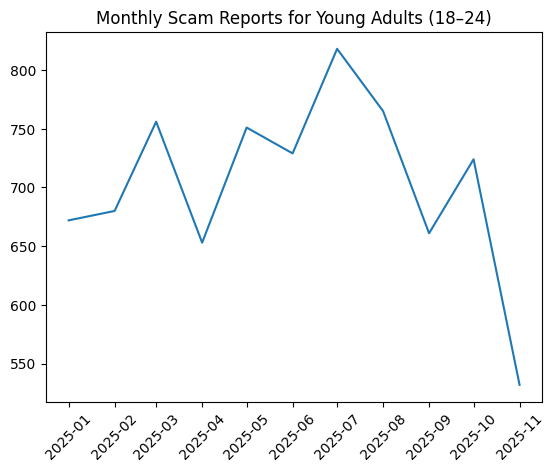

In [144]:
plt.plot(monthly['month'], monthly['reports'])
plt.title('Monthly Scam Reports for Young Adults (18–24)')
plt.xticks(rotation=45)
plt.show()

## Scam Categories

In [145]:
category_summary = (
    young_df.groupby('scam_category', as_index=False)
    .agg(
        reports=('reports', 'sum'),
        amount_lost=('amount_lost', 'sum')
    )
    .sort_values('amount_lost', ascending=False)
)

category_summary.head(10)

,scam_category,reports,amount_lost
10,Threat scams,500,7655313.08
5,Job and employment scams,728,2071032.17
4,Investment scams,327,1682487.42
2,Buying and selling scams,2255,1470359.06
9,Relationship scams,263,1436319.04
8,Phishing scams,1241,680965.81
1,Another type of scam,907,295792.66
7,Payment redirection (business email compromise...,70,264046.17
0,Account or identity takeover scams,1230,218149.87
11,Unexpected money scams,141,54682.56


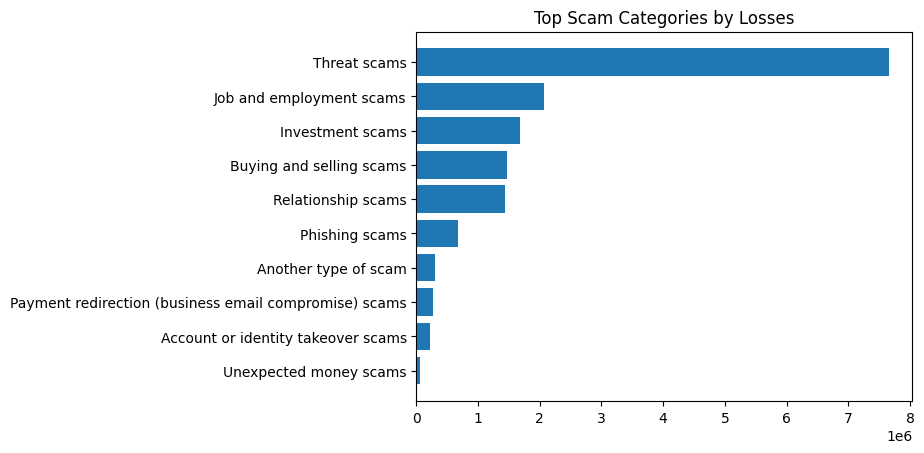

In [146]:
top10 = category_summary.head(10)

plt.barh(top10['scam_category'], top10['amount_lost'])
plt.gca().invert_yaxis()
plt.title('Top Scam Categories by Losses')
plt.show()

## Contact Modes by Age Group

In [147]:
contact_age = (
    scam_df.groupby(['age_group', 'contact_mode'], as_index=False)
    .agg(
        reports=('reports', 'sum'),
        amount_lost=('amount_lost', 'sum')
    )
)

contact_age.head()

,age_group,contact_mode,reports,amount_lost
0,18 - 24,Email,1391,1184219.84
1,18 - 24,In person,155,131631.22
2,18 - 24,Mail,98,14224.19
3,18 - 24,Online,3270,7532788.75
4,18 - 24,Phone call,1255,5827496.28


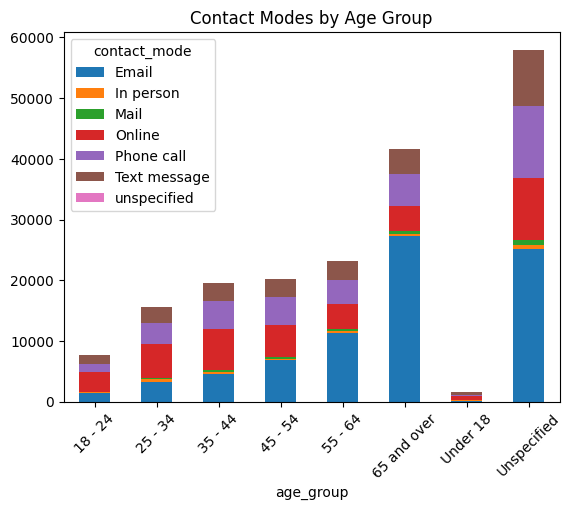

In [148]:
pivot = contact_age.pivot_table(
    index='age_group',
    columns='contact_mode',
    values='reports',
    aggfunc='sum',
    fill_value=0
)

pivot.plot(kind='bar', stacked=True)
plt.title('Contact Modes by Age Group')
plt.xticks(rotation=45)
plt.show()

## Communication Behaviour Dataset

In [149]:
comm_xls = pd.ExcelFile(COMM_FILE)
comm_xls.sheet_names[:20]

['TOC',
 'QA1. In the p by Study year',
 'QA1. In the p by PBI BANNER',
 'QA1. Apps for by Study year',
 'QA1. Apps for by PBI BANNER',
 'QE2. Which we by Study year',
 'QE2. Which we by PBI BANNER',
 'QE12. Which o by Study year',
 'QE12. Which o by PBI BANNER',
 'QE2a. Frequency of websitesapps',
 'QE2a. Frequency of websitesa(2)',
 'QE2a. Frequen by Age (consolida',
 'QE2a. Frequen by Age (consol(2)',
 'QE2a. Frequen by Gender (consol',
 'QE2a. Frequen by Gender (con(2)',
 'QE2a. Frequen by Location Metr',
 'QE2a. Frequen by Location Me(2)',
 'QE16. Used we by Study year',
 'QE16. Used we by PBI BANNER',
 'QE17. Used we by Study year']

Focus mainly on the QE17, QE12, and QE2a sheets because they contain messaging, communication, and internet behaviour data by age.

## ACMA Context Dataset

In [151]:
acma_df = pd.read_excel(ACMA_FILE)
acma_df.head(20)

ValueError: Excel file format cannot be determined, you must specify an engine manually.

Duplicate Rows Removed: 0

Missing Values Summary:


Financial Year    0
NaN               0
NaN               0
NaN               0
dtype: int64


Dataset Shape After Cleaning: (3, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Financial Year  3 non-null      object
 1   nan             3 non-null      int64 
 2   nan             3 non-null      int64 
 3   nan             3 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 228.0+ bytes


None


First 5 Rows:


,Financial Year,NaN,NaN,NaN
0,2023-24,10,0,4
1,2024-25,6,1,6
2,2025-26 (YTD),4,1,4



Statistical Summary:


,Financial Year,NaN,NaN,NaN
count,3,3.000000,3.000000,3.000000
unique,3,NaN,NaN,NaN
top,2023-24,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,6.666667,0.666667,4.666667
std,NaN,3.055050,0.577350,1.154701
min,NaN,4.000000,0.000000,4.000000
25%,NaN,5.000000,0.500000,4.000000
50%,NaN,6.000000,1.000000,4.000000
75%,NaN,8.000000,1.000000,5.000000


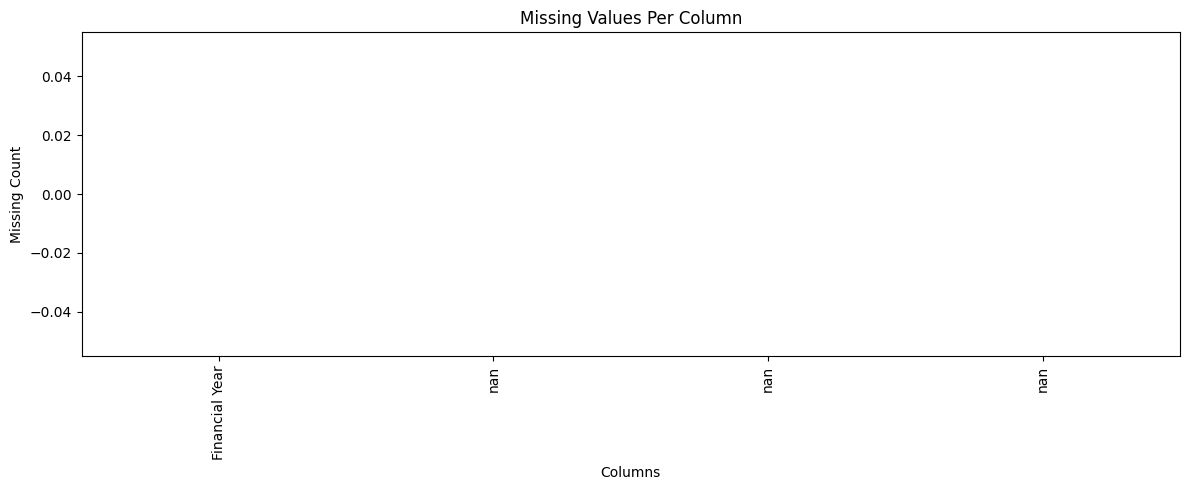

<Figure size 800x400 with 0 Axes>

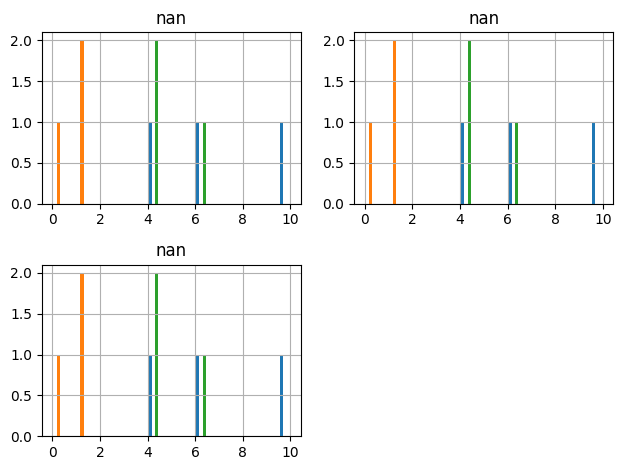

<Figure size 800x400 with 0 Axes>

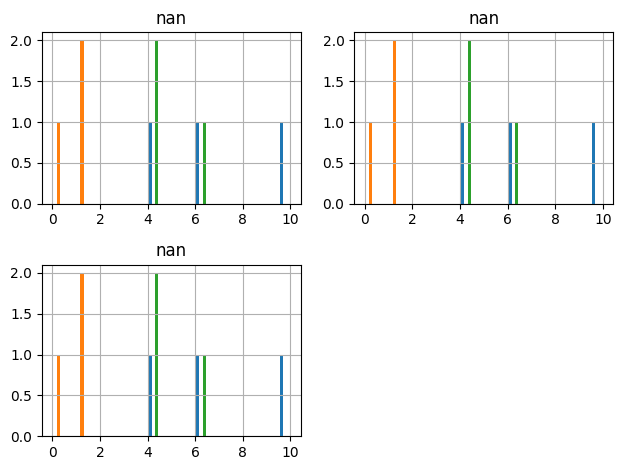

<Figure size 800x400 with 0 Axes>

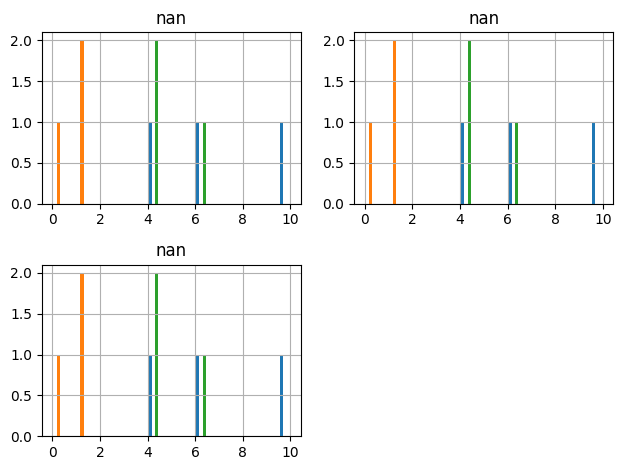

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
acma_df = pd.read_excel(ACMA_FILE)

# -------------------------------
# DATA CLEANING
# -------------------------------

# Standardise column names
acma_df.columns = acma_df.columns.str.strip()

# Remove duplicate rows
duplicates = acma_df.duplicated().sum()
print(f"Duplicate Rows Removed: {duplicates}")

acma_df = acma_df.drop_duplicates()

# Missing values
print("\nMissing Values Summary:")
display(acma_df.isnull().sum())

# Fill numeric missing values with median
numeric_cols = acma_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    acma_df[col] = acma_df[col].fillna(acma_df[col].median())

# Fill categorical missing values
categorical_cols = acma_df.select_dtypes(include='object').columns

for col in categorical_cols:
    acma_df[col] = acma_df[col].fillna("Unknown")

print("\nDataset Shape After Cleaning:", acma_df.shape)

# -------------------------------
# BASIC INFORMATION
# -------------------------------

print("\nDataset Information:")
display(acma_df.info())

print("\nFirst 5 Rows:")
display(acma_df.head())

print("\nStatistical Summary:")
display(acma_df.describe(include='all'))

# -------------------------------
# EDA VISUALISATIONS
# -------------------------------

# Plot 1 - Missing Values Heatmap Alternative
plt.figure(figsize=(12,5))
acma_df.isnull().sum().plot(kind='bar')
plt.title("Missing Values Per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot 2 - Numeric Column Distributions
for col in numeric_cols[:5]:
    plt.figure(figsize=(8,4))
    acma_df[col].hist(bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Plot 3 - Correlation Matrix
if len(numeric_cols) > 1:
    corr = acma_df[numeric_cols].corr()

    plt.figure(figsize=(10,8))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

# Plot 4 - Top Categories
for col in categorical_cols[:3]:
    plt.figure(figsize=(10,5))
    acma_df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -------------------------------
# OUTLIER DETECTION
# -------------------------------

for col in numeric_cols[:5]:
    plt.figure(figsize=(8,4))
    plt.boxplot(acma_df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

print("\nEDA Completed Successfully.")


## Export Cleaned Data

In [ ]:
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

scam_df.to_csv(OUTPUT_DIR / 'scamwatch_clean.csv', index=False)
state_summary.to_csv(OUTPUT_DIR / 'state_summary.csv', index=False)
category_summary.to_csv(OUTPUT_DIR / 'category_summary.csv', index=False)
contact_age.to_csv(OUTPUT_DIR / 'contact_age_summary.csv', index=False)

print('Export complete.')

Export complete.
